In [77]:
"""
================================================================================
АДАПТИВНЫЙ АГЕНТ ДЛЯ ПРОГНОЗИРОВАНИЯ РЫНКА
================================================================================

ИНСТРУКЦИЯ:
1. Реализуйте класс MyAgent (наследуйте от BaseAgent)
2. Заполните информацию о себе в методе get_info()
3. Реализуйте логику предсказания в predict()
4. Реализуйте определение режима в get_mode()
5. Запустите этот файл для локального тестирования
6. На паре получите от преподавателя файл test_data.py и запустите финальное тестирование
================================================================================
"""

import numpy as np
from collections import deque
import warnings
warnings.filterwarnings('ignore')


# ============================================================================
# БАЗОВЫЙ КЛАСС (НЕ ИЗМЕНЯТЬ!)
# ============================================================================

class BaseAgent:
    """
    Базовый класс для всех агентов.
    НЕ ИЗМЕНЯТЬ! Только наследовать.
    """
    
    def __init__(self):
        raise NotImplementedError("Реализуйте __init__ в вашем классе")
    
    def predict(self, features):
        """
        ПРЕДСКАЗАНИЕ НАПРАВЛЕНИЯ
        ========================
        
        Параметры:
        ----------
        features : numpy.ndarray
            Вектор признаков размером (5,)
            Индексы:
            [0] - доходность (return)
            [1] - волатильность (volatility)
            [2] - RSI (нормализованный 0-1)
            [3] - отклонение от MA20 ((price - MA20) / price)
            [4] - отклонение от MA50 ((price - MA50) / price)
        
        Возвращает:
        -----------
        int : 0 (цена упадёт) или 1 (цена вырастет)
        """
        raise NotImplementedError("Реализуйте predict в вашем классе")
    
    def get_mode(self, features):
        """
        ОПРЕДЕЛЕНИЕ РЕЖИМА РЫНКА
        ========================
        
        Параметры:
        ----------
        features : numpy.ndarray
            Вектор признаков (те же, что в predict)
        
        Возвращает:
        -----------
        int : 0 - бычий тренд
              1 - медвежий тренд
              2 - боковик/флет
              3 - высокая волатильность
        """
        raise NotImplementedError("Реализуйте get_mode в вашем классе")
    
    def get_info(self):
        """
        ИНФОРМАЦИЯ О СТУДЕНТЕ
        =====================
        Заполните своими данными!
        """
        return {
            'name': 'ФАМИЛИЯ Имя Отчество',
            'group': 'Номер группы',
            'algorithm': 'Название использованного метода',
            'n_experts': 0,
            'memory_size': 0,
            'features_used': ['return', 'volatility', 'rsi', 'ma20_diff', 'ma50_diff'],
            'description': 'Краткое описание вашей стратегии'
        }

Устройство: cuda
Размер датасета: (5220, 5)
Train: (3132, 5)
Validation: (1044, 5)
Test: (1044, 5)

Распределение режимов:


0    1261
1    1320
2    1320
3    1319
Name: count, dtype: int64


Доля роста цены по режимам:


regime
0    0.995242
1    0.003030
2    0.509091
3    0.495830
Name: target, dtype: float64

,return,volatility,rsi,ma20_diff,ma50_diff,target,price,regime
0,0.003010,0.000868,1.0,0.025069,0.074947,1,121.907315,0
1,0.002993,0.000761,1.0,0.025139,0.074612,1,122.272142,0
2,0.003512,0.000658,1.0,0.025767,0.074756,1,122.701547,0
3,0.003652,0.000632,1.0,0.026543,0.075022,1,123.149605,0
4,0.002373,0.000631,1.0,0.026078,0.074138,1,123.441838,0


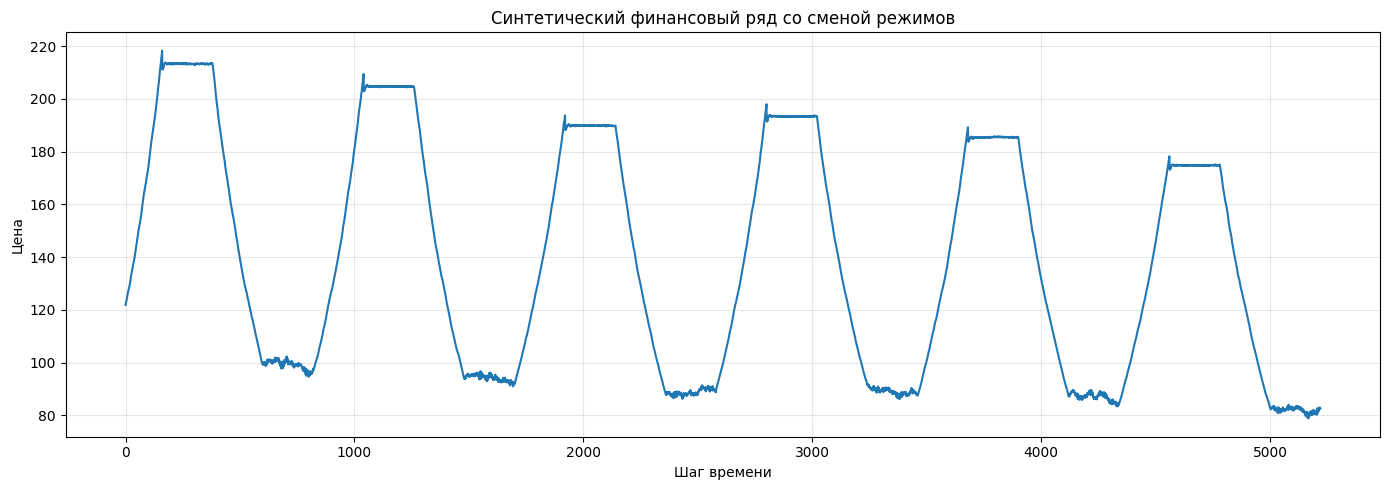

In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


RANDOM_SEED = 2027

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

output_dir = Path("results")
output_dir.mkdir(exist_ok=True)


def make_stronger_regime_switching_dataset(n_cycles=6, segment_length=220, seed=2027):
    """
    Создает финансовый ряд со сменой режимов:
    0 — бычий тренд,
    1 — медвежий тренд,
    2 — боковик,
    3 — высокая волатильность.
    """
    rng = np.random.default_rng(seed)

    regime_pattern = [0, 2, 1, 3]
    regimes = np.repeat(regime_pattern * n_cycles, segment_length)

    prices = [100.0]
    returns = [0.0]

    for regime in regimes:
        current_price = prices[-1]
        previous_return = returns[-1]

        ma20 = np.mean(prices[-20:]) if len(prices) >= 20 else current_price
        deviation = (current_price - ma20) / (current_price + 1e-8)

        if regime == 0:
            ret = 0.0028 + 0.20 * max(previous_return, 0) + rng.normal(0, 0.00075)

        elif regime == 1:
            ret = -0.0028 + 0.20 * min(previous_return, 0) + rng.normal(0, 0.00075)

        elif regime == 2:
            ret = -0.85 * deviation - 0.30 * previous_return + rng.normal(0, 0.00055)

        else:
            ret = -0.85 * previous_return + rng.normal(0, 0.0048)

        returns.append(ret)
        prices.append(current_price * (1 + ret))

    prices = np.array(prices)
    regimes = np.append(regimes[0], regimes)

    returns = pd.Series(prices).pct_change().fillna(0).values

    price_series = pd.Series(prices)
    return_series = pd.Series(returns)

    volatility = return_series.rolling(20).std().fillna(0).values

    delta = price_series.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(14).mean()
    avg_loss = losses.rolling(14).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    rsi = (100 - 100 / (1 + rs)).fillna(50).values / 100

    ma20 = price_series.rolling(20).mean().bfill().values
    ma50 = price_series.rolling(50).mean().bfill().values

    ma20_diff = (prices - ma20) / (prices + 1e-8)
    ma50_diff = (prices - ma50) / (prices + 1e-8)

    features = np.column_stack([
        returns,
        volatility,
        rsi,
        ma20_diff,
        ma50_diff
    ])

    target = (np.roll(prices, -1) > prices).astype(int)

    start = 60
    end = len(prices) - 1

    X = features[start:end]
    y = target[start:end]
    selected_prices = prices[start:end]
    selected_regimes = regimes[start:end]

    dataset = pd.DataFrame(
        X,
        columns=["return", "volatility", "rsi", "ma20_diff", "ma50_diff"]
    )

    dataset["target"] = y
    dataset["price"] = selected_prices
    dataset["regime"] = selected_regimes

    return X, y, selected_prices, selected_regimes, dataset


X_regime, y_regime, prices_regime, regimes_regime, regime_dataset = make_stronger_regime_switching_dataset()

train_end = int(len(X_regime) * 0.60)
val_end = int(len(X_regime) * 0.80)

X_regime_train = X_regime[:train_end]
y_regime_train = y_regime[:train_end]
regime_train = regimes_regime[:train_end]

X_regime_val = X_regime[train_end:val_end]
y_regime_val = y_regime[train_end:val_end]
regime_val = regimes_regime[train_end:val_end]

X_regime_test = X_regime[val_end:]
y_regime_test = y_regime[val_end:]
regime_test = regimes_regime[val_end:]

prices_regime_test = prices_regime[val_end:]

print("Устройство:", DEVICE)
print("Размер датасета:", X_regime.shape)
print("Train:", X_regime_train.shape)
print("Validation:", X_regime_val.shape)
print("Test:", X_regime_test.shape)

print()
print("Распределение режимов:")
display(pd.Series(regimes_regime).value_counts().sort_index())

print()
print("Доля роста цены по режимам:")
display(regime_dataset.groupby("regime")["target"].mean())

display(regime_dataset.head())

plt.figure(figsize=(14, 5))
plt.plot(prices_regime)
plt.title("Синтетический финансовый ряд со сменой режимов")
plt.xlabel("Шаг времени")
plt.ylabel("Цена")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "regime_switching_price.png", dpi=160)
plt.show()

In [79]:
def build_extended_features_for_agent(X, window_size=30):
    """
    Формирует расширенные признаки для экспертов и дирижёра.
    К исходным 5 признакам добавляются статистики окна последних наблюдений.
    """
    rows = []

    for i in range(len(X)):
        current = X[i]
        window = X[max(0, i - window_size + 1):i + 1]
        returns = window[:, 0]

        row = np.array([
            current[0],
            current[1],
            current[2],
            current[3],
            current[4],
            np.mean(returns),
            np.std(returns),
            np.mean(window[:, 1]),
            np.mean(window[:, 3]),
            np.mean(window[:, 4]),
            np.mean(returns > 0),
            abs(current[3]),
            abs(current[4]),
        ])

        rows.append(row)

    return np.array(rows)


X_regime_ext = build_extended_features_for_agent(X_regime, window_size=30)

X_regime_train_ext = X_regime_ext[:train_end]
X_regime_val_ext = X_regime_ext[train_end:val_end]
X_regime_test_ext = X_regime_ext[val_end:]

extended_feature_names = [
    "return",
    "volatility",
    "rsi",
    "ma20_diff",
    "ma50_diff",
    "mean_return",
    "std_return",
    "mean_volatility",
    "mean_ma20",
    "mean_ma50",
    "positive_share",
    "abs_ma20_diff",
    "abs_ma50_diff",
]

print("Размер расширенного датасета:", X_regime_ext.shape)
print("Train:", X_regime_train_ext.shape)
print("Validation:", X_regime_val_ext.shape)
print("Test:", X_regime_test_ext.shape)

display(pd.DataFrame(X_regime_ext[:5], columns=extended_feature_names))

Размер расширенного датасета: (5220, 13)
Train: (3132, 13)
Validation: (1044, 13)
Test: (1044, 13)


,return,volatility,rsi,ma20_diff,ma50_diff,mean_return,std_return,mean_volatility,mean_ma20,mean_ma50,positive_share,abs_ma20_diff,abs_ma50_diff
0,0.003010,0.000868,1.0,0.025069,0.074947,0.003010,0.000000,0.000868,0.025069,0.074947,1.0,0.025069,0.074947
1,0.002993,0.000761,1.0,0.025139,0.074612,0.003001,0.000009,0.000815,0.025104,0.074780,1.0,0.025139,0.074612
2,0.003512,0.000658,1.0,0.025767,0.074756,0.003172,0.000241,0.000762,0.025325,0.074772,1.0,0.025767,0.074756
3,0.003652,0.000632,1.0,0.026543,0.075022,0.003292,0.000294,0.000730,0.025629,0.074834,1.0,0.026543,0.075022
4,0.002373,0.000631,1.0,0.026078,0.074138,0.003108,0.000452,0.000710,0.025719,0.074695,1.0,0.026078,0.074138


In [80]:
import copy


class MLPExpert(nn.Module):
    """
    Небольшая нейронная сеть-эксперт для бинарного прогноза направления цены.
    """
    
    def __init__(self, input_size, hidden_size=12):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)


nn_specialist_specs = [
    {
        "name": "Expert 1: Bull trend MLP",
        "description": "нейросеть для бычьего тренда",
        "mask": regime_train == 0,
        "val_mask": regime_val == 0,
        "hidden_size": 10,
        "epochs": 80,
        "learning_rate": 0.003,
    },
    {
        "name": "Expert 2: Bear trend MLP",
        "description": "нейросеть для медвежьего тренда",
        "mask": regime_train == 1,
        "val_mask": regime_val == 1,
        "hidden_size": 10,
        "epochs": 80,
        "learning_rate": 0.003,
    },
    {
        "name": "Expert 3: Flat MLP",
        "description": "нейросеть для боковика",
        "mask": regime_train == 2,
        "val_mask": regime_val == 2,
        "hidden_size": 14,
        "epochs": 90,
        "learning_rate": 0.002,
    },
    {
        "name": "Expert 4: High volatility MLP",
        "description": "нейросеть для высокой волатильности",
        "mask": regime_train == 3,
        "val_mask": regime_val == 3,
        "hidden_size": 14,
        "epochs": 90,
        "learning_rate": 0.002,
    },
    {
        "name": "Expert 5: Mean reversion MLP",
        "description": "нейросеть возврата к среднему",
        "mask": (regime_train == 2) | (regime_train == 3),
        "val_mask": (regime_val == 2) | (regime_val == 3),
        "hidden_size": 12,
        "epochs": 90,
        "learning_rate": 0.002,
    },
]


def predict_mlp_proba(model, scaler, X_data):
    """
    Возвращает вероятности роста цены для MLP-эксперта.
    """
    model.eval()
    
    X_scaled = scaler.transform(X_data)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)
    
    with torch.no_grad():
        logits = model(X_tensor)
        probabilities = torch.sigmoid(logits).cpu().numpy()
    
    return probabilities


def fit_mlp_expert(spec):
    """
    Обучает одного MLP-эксперта на данных выбранного режима.
    """
    train_mask = spec["mask"]
    val_mask = spec["val_mask"]
    
    X_train_part = X_regime_train_ext[train_mask]
    y_train_part = y_regime_train[train_mask]
    
    X_val_part = X_regime_val_ext[val_mask]
    y_val_part = y_regime_val[val_mask]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_part)
    
    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train_part, dtype=torch.float32)
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True
    )
    
    model = MLPExpert(
        input_size=X_regime_train_ext.shape[1],
        hidden_size=spec["hidden_size"]
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=spec["learning_rate"]
    )
    
    criterion = nn.BCEWithLogitsLoss()
    
    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1
    
    for epoch in range(1, spec["epochs"] + 1):
        model.train()
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
        
        val_probabilities = predict_mlp_proba(model, scaler, X_val_part)
        val_predictions = (val_probabilities >= 0.5).astype(int)
        val_accuracy = accuracy_score(y_val_part, val_predictions)
        
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = copy.deepcopy(model.state_dict())
    
    model.load_state_dict(best_state)
    
    return {
        "name": spec["name"],
        "description": spec["description"],
        "model": model,
        "scaler": scaler,
        "train_size": int(train_mask.sum()),
        "best_regime_val_accuracy": best_val_accuracy
    }


nn_experts = []

for spec in nn_specialist_specs:
    print("Обучение:", spec["name"])
    expert = fit_mlp_expert(spec)
    nn_experts.append(expert)
    print("Лучшая accuracy внутри своего режима:", round(expert["best_regime_val_accuracy"], 4))
    print()


val_nn_probabilities = np.column_stack([
    predict_mlp_proba(expert["model"], expert["scaler"], X_regime_val_ext)
    for expert in nn_experts
])

test_nn_probabilities = np.column_stack([
    predict_mlp_proba(expert["model"], expert["scaler"], X_regime_test_ext)
    for expert in nn_experts
])


nn_report_rows = []

for expert_id, expert in enumerate(nn_experts):
    val_predictions = (val_nn_probabilities[:, expert_id] >= 0.5).astype(int)
    test_predictions = (test_nn_probabilities[:, expert_id] >= 0.5).astype(int)
    
    nn_report_rows.append({
        "Эксперт": expert["name"],
        "Описание": expert["description"],
        "Train size": expert["train_size"],
        "Best regime validation accuracy": expert["best_regime_val_accuracy"],
        "Validation accuracy": accuracy_score(y_regime_val, val_predictions),
        "Test accuracy": accuracy_score(y_regime_test, test_predictions),
    })

nn_report_df = pd.DataFrame(nn_report_rows)

display(nn_report_df)

Обучение: Expert 1: Bull trend MLP
Лучшая accuracy внутри своего режима: 0.9955

Обучение: Expert 2: Bear trend MLP
Лучшая accuracy внутри своего режима: 0.9939

Обучение: Expert 3: Flat MLP
Лучшая accuracy внутри своего режима: 0.8

Обучение: Expert 4: High volatility MLP
Лучшая accuracy внутри своего режима: 0.8509

Обучение: Expert 5: Mean reversion MLP
Лучшая accuracy внутри своего режима: 0.7919



,Эксперт,Описание,Train size,Best regime validation accuracy,Validation accuracy,Test accuracy
0,Expert 1: Bull trend MLP,нейросеть для бычьего тренда,821,0.995455,0.701149,0.644636
1,Expert 2: Bear trend MLP,нейросеть для медвежьего тренда,771,0.993921,0.765326,0.712644
2,Expert 3: Flat MLP,нейросеть для боковика,880,0.800000,0.356322,0.445402
3,Expert 4: High volatility MLP,нейросеть для высокой волатильности,660,0.850909,0.374521,0.449234
4,Expert 5: Mean reversion MLP,нейросеть возврата к среднему,1540,0.791919,0.573755,0.674330


In [81]:
torch_experts = []

for expert in nn_experts:
    model_cpu = copy.deepcopy(expert["model"]).cpu()
    hidden_size = model_cpu.network[0].out_features

    torch_experts.append({
        "hidden_size": hidden_size,
        "scaler_mean": torch.tensor(expert["scaler"].mean_, dtype=torch.float32),
        "scaler_scale": torch.tensor(expert["scaler"].scale_, dtype=torch.float32),
        "state_dict": model_cpu.network.state_dict(),
    })

torch.save(
    {
        "input_size": X_regime_train_ext.shape[1],
        "experts": torch_experts,
    },
    "mlp_experts_torch.pt"
)

print("Файл с MLP-экспертами сохранён: mlp_experts_torch.pt")

Файл с MLP-экспертами сохранён: mlp_experts_torch.pt


In [ ]:
# ============================================================================
# ВАШ АГЕНТ (РЕАЛИЗУЙТЕ ЗДЕСЬ)
# ============================================================================

class MyAgent(BaseAgent):
    """
    АДАПТИВНЫЙ АГЕНТ
    ====================
    Реализуйте здесь свою логику.
    """
    
    def __init__(self):
        """
        ИНИЦИАЛИЗАЦИЯ АГЕНТА
        ====================
        Здесь вы должны:
        1. Загрузить или создать экспертов
        2. Оптимизировать параметры
        3. Инициализировать память для анализа окна данных
        """
        print("Инициализация адаптивного агента...")
        
        import torch
        from torch import nn
        
        self.torch = torch
        self.nn = nn
        
        self.thresholds = {
            'trend_up': 0.00075,
            'trend_down': -0.00075,
            'volatility_high': 0.0032,
            'rsi_oversold': 30,
            'rsi_overbought': 70,
        }
        
        self.window_size = 30
        self.memory = deque(maxlen=self.window_size)
        
        self.experts = []
        self._load_experts()
        
        self.mode_to_experts = {
            0: [(0, 1.0)],
            1: [(1, 1.0)],
            2: [(2, 0.7), (4, 0.3)],
            3: [(3, 1.0)],
        }
        
        self.current_mode = 2
        self.candidate_mode = None
        self.candidate_count = 0
        self.switch_confirmation = 3
        
        self.last_mode = None
        self.switch_count = 0
        self.mode_history = []
        self.expert_history = []
        self.expert_group_history = []
        self.prediction_history = []
        
        print("Агент готов")
    
    def _load_experts(self):
        """Загружает 5 предобученных MLP-экспертов из файла."""
        import os
        
        path = "mlp_experts_torch.pt"
        
        if not os.path.exists(path):
            base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
            path = os.path.join(base_dir, "mlp_experts_torch.pt")
        
        try:
            checkpoint = self.torch.load(path, map_location="cpu", weights_only=True)
        except TypeError:
            checkpoint = self.torch.load(path, map_location="cpu")
        
        input_size = checkpoint["input_size"]
        
        for item in checkpoint["experts"]:
            model = self.nn.Sequential(
                self.nn.Linear(input_size, int(item["hidden_size"])),
                self.nn.Tanh(),
                self.nn.Linear(int(item["hidden_size"]), 1)
            )
            
            model.load_state_dict(item["state_dict"])
            model.eval()
            
            self.experts.append({
                "model": model,
                "scaler_mean": item["scaler_mean"].numpy(),
                "scaler_scale": item["scaler_scale"].numpy(),
            })
    
    def _predict_mode_probability(self, mode, extended_features):
        """Считает итоговую вероятность для режима с учётом одного или нескольких экспертов."""
        expert_group = self.mode_to_experts[mode]
        probability = 0.0

        for expert_index, weight in expert_group:
            probability += weight * self._predict_expert_probability(
                expert_index,
                extended_features
            )

        return float(probability)

    def _window_array(self):
        """Возвращает память агента как numpy-массив."""
        if len(self.memory) == 0:
            return np.zeros((1, 5))
        return np.array(self.memory)
    
    def _make_extended_features(self, features):
        """Формирует 13 признаков из текущего вектора и краткосрочной памяти."""
        features = np.asarray(features, dtype=float)
        window = self._window_array()
        returns = window[:, 0]
        
        extended = np.array([
            features[0], # текущая доходность
            features[1], # текущая волатильность
            features[2], # текущий RSI
            features[3], # отклонение от MA20
            features[4], # отклонение от MA50
            np.mean(returns), # средняя доходность
            np.std(returns), # стандартное отклонение доходности
            np.mean(window[:, 1]), # средняя волатильность
            np.mean(window[:, 3]), # средний RSI
            np.mean(window[:, 4]), # среднее отклонение от MA50
            np.mean(returns > 0), # доля положительных шагов
            abs(features[3]), # абсолютное отклонение от MA20
            abs(features[4]), # абсолютное отклонение от MA50
        ], dtype=float)
        
        return extended
    
    def _detect_raw_mode(self, extended_features):
        """Определяет сырой режим среды без гистерезиса."""
        volatility = extended_features[1]
        mean_return = extended_features[5]
        std_return = extended_features[6]
        positive_share = extended_features[10]
        mean_ma20 = extended_features[8]
        
        if volatility > self.thresholds['volatility_high'] or std_return > self.thresholds['volatility_high']:
            return 3 # высокая волатильность
        
        if mean_return > self.thresholds['trend_up'] and positive_share > 0.55 and mean_ma20 > 0:
            return 0 # бычий тренд
        
        if mean_return < self.thresholds['trend_down'] and positive_share < 0.45 and mean_ma20 < 0:
            return 1 # медвежий тренд
        
        return 2 # боковик/флет
    
    def _apply_hysteresis(self, raw_mode):
        """Подтверждает смену режима, чтобы агент не переключался слишком часто."""
        if raw_mode == self.current_mode:
            self.candidate_mode = None
            self.candidate_count = 0
            return self.current_mode
        
        if raw_mode == self.candidate_mode:
            self.candidate_count += 1
        else:
            self.candidate_mode = raw_mode
            self.candidate_count = 1
        
        if self.candidate_count >= self.switch_confirmation:
            self.current_mode = raw_mode
            self.switch_count += 1
            self.candidate_mode = None
            self.candidate_count = 0
        
        return self.current_mode
    
    def _predict_expert_probability(self, expert_index, extended_features):
        """Считает вероятность роста выбранным MLP-экспертом."""
        expert = self.experts[expert_index]
        
        # Нормализация признаков для эксперта
        x_scaled = (
            extended_features - expert["scaler_mean"]
        ) / (expert["scaler_scale"] + 1e-8)
        
        # Преобразуем в тензор и добавляем размерность батча
        x_tensor = self.torch.tensor(
            x_scaled,
            dtype=self.torch.float32
        ).unsqueeze(0)
        
        # Получаем логит от эксперта и преобразуем в вероятность
        with self.torch.no_grad():
            logit = expert["model"](x_tensor).squeeze()
            probability = self.torch.sigmoid(logit).item()
        
        return probability
    
    def get_mode(self, features):
        """
        ОПРЕДЕЛЕНИЕ РЕЖИМА РЫНКА
        ========================
        Использует пороги для классификации текущего состояния рынка.
        """
        extended_features = self._make_extended_features(features)
        return self._detect_raw_mode(extended_features) # Сырой режим без защиты от переключений
    
    def predict(self, features):
        """
        ПРЕДСКАЗАНИЕ НАПРАВЛЕНИЯ
        ========================
        
        Анализирует окно последних данных (self.memory) и 
        принимает решение о направлении движения цены.
        """
        features = np.asarray(features, dtype=float)
        
        self.memory.append(features)
        
        extended_features = self._make_extended_features(features)
        raw_mode = self._detect_raw_mode(extended_features)
        mode = self._apply_hysteresis(raw_mode)
        
        expert_group = self.mode_to_experts[mode]
        probability = self._predict_mode_probability(mode, extended_features)

        prediction = int(probability >= 0.5)

        main_expert_index = expert_group[0][0]
        expert_group_indices = tuple(expert_index for expert_index, _ in expert_group)

        self.last_mode = mode
        self.mode_history.append(mode)
        self.expert_history.append(main_expert_index)
        self.expert_group_history.append(expert_group_indices)
        self.prediction_history.append(prediction)

        return prediction
    
    def get_info(self):
        """ДАННЫЕ"""
        return {
            'name': 'Мотынга Сергей',
            'group': 'ФИТ-231',
            'algorithm': 'Adaptive MLP State Machine Director',
            'n_experts': 5,
            'memory_size': self.window_size,
            'features_used': ['return', 'volatility', 'rsi', 'ma20_diff', 'ma50_diff'],
            'description': (
                'Адаптивный агент с 5 предобученными MLP-экспертами, '
                'краткосрочной памятью и State Machine-дирижёром для выбора режима.'
            )
        }

In [83]:
# ============================================================================
# ЛОКАЛЬНОЕ ТЕСТИРОВАНИЕ (ДЛЯ ПРОВЕРКИ ДОМА)
# ============================================================================

class LocalTester:
    """Локальный тестер для проверки агента дома"""
    
    @staticmethod
    def test(agent):
        """Тестирование агента на синтетических данных"""
        np.random.seed(42)
        
        # Генерация простых тестовых данных
        prices = [100]
        for i in range(500):
            prices.append(prices[-1] + np.random.normal(0, 1))
        prices = np.array(prices)
        
        # Вычисление признаков
        returns = np.diff(prices) / prices[:-1]
        returns = np.append([0], returns)
        
        volatility = np.zeros(len(prices))
        for i in range(20, len(prices)):
            volatility[i] = np.std(returns[i-20:i])
        
        rsi = np.zeros(len(prices))
        for i in range(14, len(prices)):
            gains = returns[i-14:i][returns[i-14:i] > 0].sum()
            losses = -returns[i-14:i][returns[i-14:i] < 0].sum()
            rsi[i] = 50 if losses == 0 else 100 - 100/(1 + gains/losses)
        
        ma_20 = np.zeros(len(prices))
        for i in range(20, len(prices)):
            ma_20[i] = np.mean(prices[i-20:i])
        
        features = np.column_stack([
            returns, volatility, rsi/100,
            (prices - ma_20)/(prices + 1e-8),
            np.zeros(len(prices))
        ])
        
        target = (np.roll(prices, -1) > prices).astype(int)
        
        X = features[50:-1]
        y = target[50:-1]
        
        predictions = []
        switches = 0
        last_mode = None
        
        for f in X:
            predictions.append(agent.predict(f))
            mode = agent.get_mode(f)
            if last_mode is not None and last_mode != mode:
                switches += 1
            last_mode = mode
        
        accuracy = np.mean(np.array(predictions) == y)
        
        print("\n" + "="*60)
        print("ЛОКАЛЬНОЕ ТЕСТИРОВАНИЕ")
        print("="*60)
        print(f"   Точность: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"   Переключений: {switches}")
        print(f"   Частота: {switches/len(X)*100:.1f}%")
        
        info = agent.get_info()
        print(f"\nСТУДЕНТ:")
        print(f"   ФИО: {info['name']}")
        print(f"   Группа: {info['group']}")
        print(f"   Метод: {info['algorithm']}")
        
        return accuracy

In [84]:
# ============================================================================
# ЗАПУСК ДОМАШНЕГО ТЕСТИРОВАНИЯ
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print("ДОМАШНЕЕ ТЕСТИРОВАНИЕ АГЕНТА")
    print("="*60)
    
    # Создаём агента
    agent = MyAgent()
    
    # Запускаем тестирование
    accuracy = LocalTester.test(agent)
    
    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
    print("   На паре вы получите файл test_data.py")
    print("="*60)

ДОМАШНЕЕ ТЕСТИРОВАНИЕ АГЕНТА
Инициализация адаптивного агента...
Агент готов

ЛОКАЛЬНОЕ ТЕСТИРОВАНИЕ
   Точность: 0.5022 (50.22%)
   Переключений: 0
   Частота: 0.0%

СТУДЕНТ:
   ФИО: Мотынга Сергей
   Группа: ФИТ-231
   Метод: Adaptive MLP State Machine Director

ТЕСТИРОВАНИЕ ЗАВЕРШЕНО
   На паре вы получите файл test_data.py


In [92]:
def count_model_parameters(model):
    """
    Считает количество обучаемых параметров PyTorch-модели.
    """
    return sum(parameter.numel() for parameter in model.parameters())


agent_for_resources = full_agent_result["agent"]

expert_parameter_rows = []

for expert_id, expert in enumerate(agent_for_resources.experts):
    parameter_count = count_model_parameters(expert["model"])
    
    expert_parameter_rows.append({
        "Эксперт": expert_id + 1,
        "Название эксперта": expert_names[expert_id],
        "Количество параметров": parameter_count
    })

expert_parameters_df = pd.DataFrame(expert_parameter_rows)

print("Количество параметров каждого MLP-эксперта:")
display(expert_parameters_df)

Количество параметров каждого MLP-эксперта:


,Эксперт,Название эксперта,Количество параметров
0,1,Expert 1: Bull trend MLP,151
1,2,Expert 2: Bear trend MLP,151
2,3,Expert 3: Flat MLP,211
3,4,Expert 4: High volatility MLP,211
4,5,Expert 5: Mean reversion MLP,181


In [85]:
mode_names = {
    0: "Бычий тренд",
    1: "Медвежий тренд",
    2: "Боковик/флет",
    3: "Высокая волатильность"
}

expert_names = {
    0: "Expert 1: Bull trend MLP",
    1: "Expert 2: Bear trend MLP",
    2: "Expert 3: Flat MLP",
    3: "Expert 4: High volatility MLP",
    4: "Expert 5: Mean reversion MLP"
}


def count_switches(sequence):
    """
    Считает количество переключений в последовательности режимов или экспертов.
    """
    sequence = np.asarray(sequence)

    if len(sequence) <= 1:
        return 0

    return int(np.sum(sequence[1:] != sequence[:-1]))


def evaluate_myagent_on_sequence(X_data):
    """
    Прогоняет финальный MyAgent по последовательности признаков.
    """
    final_agent = MyAgent()
    predictions = []

    for features in X_data:
        predictions.append(final_agent.predict(features))

    return {
        "agent": final_agent,
        "predictions": np.array(predictions),
        "modes": np.array(final_agent.mode_history),
        "experts": np.array(final_agent.expert_history),
        "expert_groups": np.array(final_agent.expert_group_history, dtype=object),
    }


full_agent_result = evaluate_myagent_on_sequence(X_regime)

val_predictions_agent = full_agent_result["predictions"][train_end:val_end]
test_predictions_agent = full_agent_result["predictions"][val_end:]

val_modes_agent = full_agent_result["modes"][train_end:val_end]
test_modes_agent = full_agent_result["modes"][val_end:]

val_experts_agent = full_agent_result["experts"][train_end:val_end]
test_experts_agent = full_agent_result["experts"][val_end:]

val_agent_accuracy = accuracy_score(y_regime_val, val_predictions_agent)
test_agent_accuracy = accuracy_score(y_regime_test, test_predictions_agent)

val_agent_switches = count_switches(val_experts_agent)
test_agent_switches = count_switches(test_experts_agent)

best_single_val = nn_report_df["Validation accuracy"].max()
best_single_test = nn_report_df["Test accuracy"].max()

final_agent_summary_df = pd.DataFrame([
    {
        "Метод": "Best single MLP specialist",
        "Validation accuracy": best_single_val,
        "Test accuracy": best_single_test,
        "Переключений на validation": 0,
        "Переключений на test": 0,
        "Количество экспертов": 1
    },
    {
        "Метод": "Adaptive MLP MyAgent",
        "Validation accuracy": val_agent_accuracy,
        "Test accuracy": test_agent_accuracy,
        "Переключений на validation": val_agent_switches,
        "Переключений на test": test_agent_switches,
        "Количество экспертов": 5
    }
])

print("Итоговое сравнение через финальный MyAgent:")
display(final_agent_summary_df)

print("Прирост на validation:", round(val_agent_accuracy - best_single_val, 4))
print("Прирост на test:", round(test_agent_accuracy - best_single_test, 4))
print(
    "Относительный прирост на test, %:",
    round((test_agent_accuracy - best_single_test) / best_single_test * 100, 2)
)

print()
print("Распределение режимов MyAgent на test:")
display(pd.Series(test_modes_agent).value_counts().sort_index())

print()
print("Распределение выбранных MLP-экспертов MyAgent на test:")
display(pd.Series(test_experts_agent + 1).value_counts().sort_index())

Инициализация адаптивного агента...
Агент готов
Итоговое сравнение через финальный MyAgent:


,Метод,Validation accuracy,Test accuracy,Переключений на validation,Переключений на test,Количество экспертов
0,Best single MLP specialist,0.765326,0.712644,0,0,1
1,Adaptive MLP MyAgent,0.878352,0.853448,6,5,5


Прирост на validation: 0.113
Прирост на test: 0.1408
Относительный прирост на test, %: 19.76

Распределение режимов MyAgent на test:


0    199
1    228
2    197
3    420
Name: count, dtype: int64


Распределение выбранных MLP-экспертов MyAgent на test:


1    199
2    228
3    197
4    420
Name: count, dtype: int64

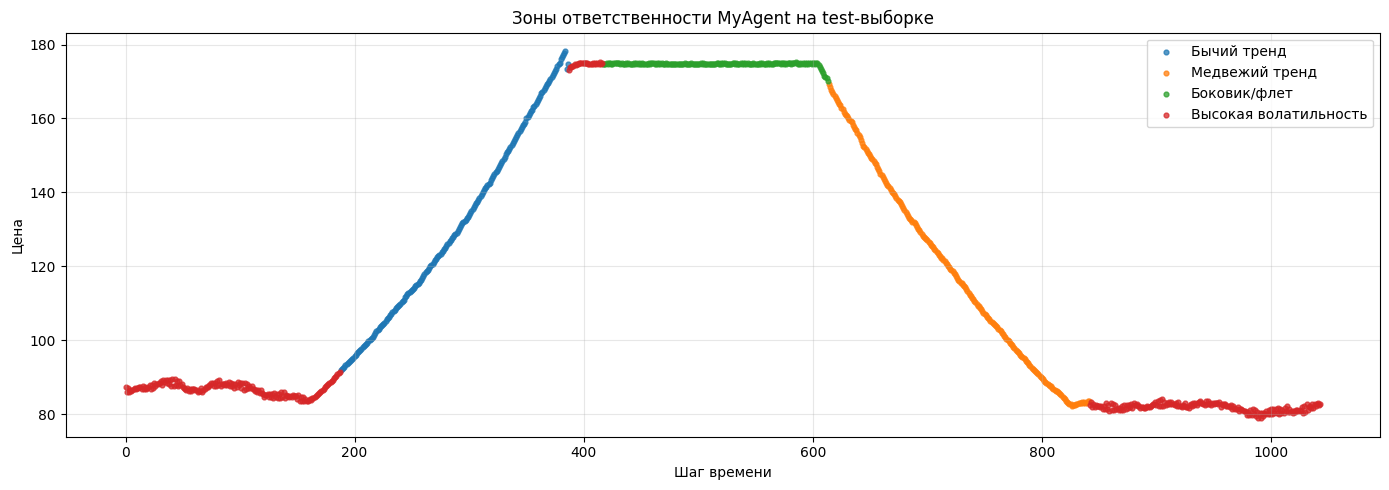

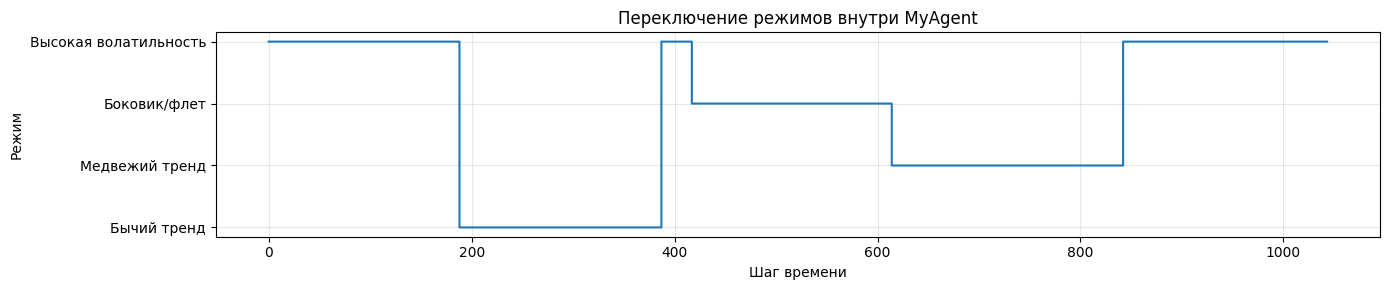

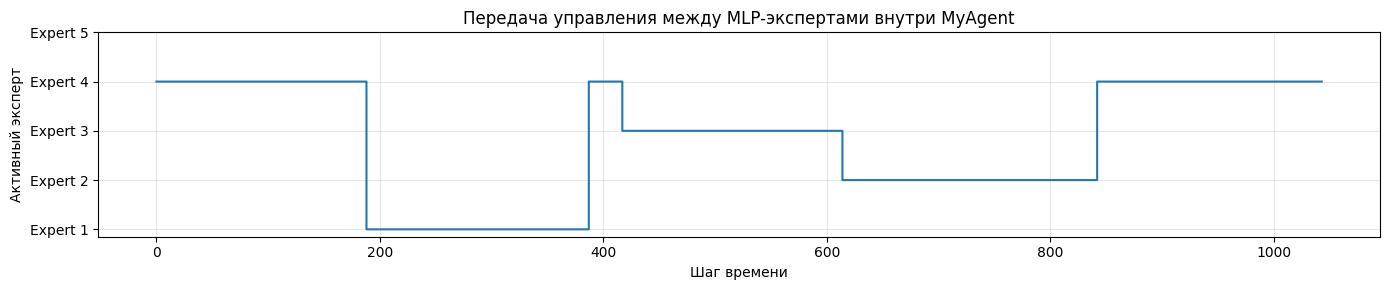

In [86]:
time_index = np.arange(len(prices_regime_test))

plt.figure(figsize=(14, 5))

for mode_id, mode_name in mode_names.items():
    mask = test_modes_agent == mode_id

    plt.scatter(
        time_index[mask],
        prices_regime_test[mask],
        s=12,
        alpha=0.75,
        label=mode_name
    )

plt.title("Зоны ответственности MyAgent на test-выборке")
plt.xlabel("Шаг времени")
plt.ylabel("Цена")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "myagent_responsibility_zones.png", dpi=160)
plt.show()


plt.figure(figsize=(14, 3))
plt.plot(time_index, test_modes_agent, drawstyle="steps-post")
plt.yticks([0, 1, 2, 3], [mode_names[i] for i in [0, 1, 2, 3]])
plt.title("Переключение режимов внутри MyAgent")
plt.xlabel("Шаг времени")
plt.ylabel("Режим")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "myagent_modes.png", dpi=160)
plt.show()


plt.figure(figsize=(14, 3))
plt.plot(time_index, test_experts_agent + 1, drawstyle="steps-post")
plt.yticks([1, 2, 3, 4, 5], [f"Expert {i}" for i in [1, 2, 3, 4, 5]])
plt.title("Передача управления между MLP-экспертами внутри MyAgent")
plt.xlabel("Шаг времени")
plt.ylabel("Активный эксперт")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "myagent_expert_switching.png", dpi=160)
plt.show()

In [96]:
def count_model_parameters(model):
    """
    Считает количество обучаемых параметров PyTorch-модели.
    """
    return sum(parameter.numel() for parameter in model.parameters())


agent_for_resources = full_agent_result["agent"]


# -----------------------------
# 1. Количество параметров каждого эксперта
# -----------------------------

expert_parameter_rows = []

for expert_id, expert in enumerate(agent_for_resources.experts):
    parameter_count = count_model_parameters(expert["model"])

    expert_parameter_rows.append({
        "Эксперт": expert_id + 1,
        "Название эксперта": expert_names[expert_id],
        "Количество параметров": parameter_count
    })

expert_parameters_df = pd.DataFrame(expert_parameter_rows)


# -----------------------------
# 2. Таблица ресурсов по режимам
# -----------------------------

resource_rows = []

for mode_id, expert_group in agent_for_resources.mode_to_experts.items():
    expert_ids = [expert_index for expert_index, _ in expert_group]
    expert_weights = [weight for _, weight in expert_group]

    active_parameter_count = sum(
        expert_parameters_df.loc[
            expert_parameters_df["Эксперт"] == expert_id + 1,
            "Количество параметров"
        ].values[0]
        for expert_id in expert_ids
    )

    expert_numbers = [expert_id + 1 for expert_id in expert_ids]

    expert_labels = [
        f"{expert_names[expert_id]} ({weight:.1f})"
        for expert_id, weight in zip(expert_ids, expert_weights)
    ]

    resource_rows.append({
        "Режим": mode_id,
        "Название режима": mode_names[mode_id],
        "Активные эксперты": expert_numbers,
        "Название экспертов": " + ".join(expert_labels),
        "Количество активных экспертов": len(expert_ids),
        "Активных параметров на шаг": active_parameter_count,
        "Логика выбора": f"{mode_names[mode_id]} -> " + " + ".join(expert_labels)
    })

resources_df = pd.DataFrame(resource_rows)


# -----------------------------
# 3. Распределение режимов на test
# -----------------------------

mode_counts = pd.Series(test_modes_agent).value_counts().sort_index()

mode_usage_df = pd.DataFrame({
    "Режим": mode_counts.index,
    "Название режима": [mode_names[i] for i in mode_counts.index],
    "Количество шагов": mode_counts.values,
    "Доля времени": mode_counts.values / len(test_modes_agent)
})


# -----------------------------
# 4. Распределение участия экспертов на test
# -----------------------------

expert_participation = {expert_id: 0 for expert_id in range(5)}
expert_weighted_participation = {expert_id: 0.0 for expert_id in range(5)}

for mode in test_modes_agent:
    expert_group = agent_for_resources.mode_to_experts[mode]

    for expert_id, weight in expert_group:
        expert_participation[expert_id] += 1
        expert_weighted_participation[expert_id] += weight

expert_usage_rows = []

for expert_id in range(5):
    expert_usage_rows.append({
        "Эксперт": expert_id + 1,
        "Название эксперта": expert_names[expert_id],
        "Количество шагов участия": expert_participation[expert_id],
        "Доля шагов участия": expert_participation[expert_id] / len(test_modes_agent),
        "Взвешенное участие": expert_weighted_participation[expert_id],
        "Средняя весовая доля": expert_weighted_participation[expert_id] / len(test_modes_agent)
    })

expert_usage_df = pd.DataFrame(expert_usage_rows)


# -----------------------------
# 5. Ресурсы, задействованные на test-интервале
# -----------------------------

resource_by_time_rows = []

for mode_id in sorted(np.unique(test_modes_agent)):
    mode_mask = test_modes_agent == mode_id
    steps_count = int(mode_mask.sum())

    expert_group = agent_for_resources.mode_to_experts[mode_id]
    expert_ids = [expert_index for expert_index, _ in expert_group]

    active_parameter_count = sum(
        expert_parameters_df.loc[
            expert_parameters_df["Эксперт"] == expert_id + 1,
            "Количество параметров"
        ].values[0]
        for expert_id in expert_ids
    )

    resource_by_time_rows.append({
        "Режим": mode_id,
        "Название режима": mode_names[mode_id],
        "Количество шагов на test": steps_count,
        "Доля test-времени": steps_count / len(test_modes_agent),
        "Количество активных экспертов": len(expert_ids),
        "Активных параметров на шаг": active_parameter_count
    })

resource_by_time_df = pd.DataFrame(resource_by_time_rows)


# -----------------------------
# 6. Итоговые метрики
# -----------------------------

final_metrics_df = pd.DataFrame([
    {
        "Метрика": "Accuracy лучшей одиночной MLP",
        "Значение": best_single_test
    },
    {
        "Метрика": "Accuracy адаптивного MyAgent",
        "Значение": test_agent_accuracy
    },
    {
        "Метрика": "Абсолютный прирост",
        "Значение": test_agent_accuracy - best_single_test
    },
    {
        "Метрика": "Относительный прирост, %",
        "Значение": (test_agent_accuracy - best_single_test) / best_single_test * 100
    },
    {
        "Метрика": "Переключений на test",
        "Значение": test_agent_switches
    },
    {
        "Метрика": "Количество MLP-экспертов в библиотеке",
        "Значение": 5
    }
])


# -----------------------------
# 7. Вывод таблиц
# -----------------------------

print("Итоговое сравнение:")
display(final_agent_summary_df)

print("Количество параметров каждого MLP-эксперта:")
display(expert_parameters_df)

print("Таблица ресурсов по режимам:")
display(resources_df)

print("Распределение режимов MyAgent на test:")
display(mode_usage_df)

print("Распределение участия экспертов MyAgent на test:")
display(expert_usage_df)

print("Ресурсы, задействованные на test-интервале:")
display(resource_by_time_df)

print("Итоговые метрики:")
display(final_metrics_df)

print("Краткий итог:")
print("Accuracy лучшей одиночной MLP:", round(best_single_test, 4))
print("Accuracy адаптивного MyAgent:", round(test_agent_accuracy, 4))
print("Абсолютный прирост:", round(test_agent_accuracy - best_single_test, 4))
print(
    "Относительный прирост, %:",
    round((test_agent_accuracy - best_single_test) / best_single_test * 100, 2)
)
print("Переключений на test:", test_agent_switches)

Итоговое сравнение:


,Метод,Validation accuracy,Test accuracy,Переключений на validation,Переключений на test,Количество экспертов
0,Best single MLP specialist,0.765326,0.712644,0,0,1
1,Adaptive MLP MyAgent,0.878352,0.853448,6,5,5


Количество параметров каждого MLP-эксперта:


,Эксперт,Название эксперта,Количество параметров
0,1,Expert 1: Bull trend MLP,151
1,2,Expert 2: Bear trend MLP,151
2,3,Expert 3: Flat MLP,211
3,4,Expert 4: High volatility MLP,211
4,5,Expert 5: Mean reversion MLP,181


Таблица ресурсов по режимам:


...

Ресурсы, задействованные на test-интервале:


,Режим,Название режима,Количество шагов на test,Доля test-времени,Количество активных экспертов,Активных параметров на шаг
0,0,Бычий тренд,199,0.190613,1,151
1,1,Медвежий тренд,228,0.218391,1,151
2,2,Боковик/флет,197,0.188697,2,392
3,3,Высокая волатильность,420,0.402299,1,211


Итоговые метрики:


,Метрика,Значение
0,Accuracy лучшей одиночной MLP,0.712644
1,Accuracy адаптивного MyAgent,0.853448
2,Абсолютный прирост,0.140805
3,"Относительный прирост, %",19.758065
4,Переключений на test,5.000000
5,Количество MLP-экспертов в библиотеке,5.000000


Краткий итог:
Accuracy лучшей одиночной MLP: 0.7126
Accuracy адаптивного MyAgent: 0.8534
Абсолютный прирост: 0.1408
Относительный прирост, %: 19.76
Переключений на test: 5


In [88]:
def add_feature_noise(X_data, noise_level=0.10, seed=2028):
    """
    Добавляет шум к признакам test-выборки.
    noise_level задаёт силу шума относительно стандартного отклонения каждого признака.
    """
    rng = np.random.default_rng(seed)
    
    feature_std = X_data.std(axis=0)
    noise = rng.normal(
        loc=0,
        scale=noise_level * feature_std,
        size=X_data.shape
    )
    
    X_noisy = X_data + noise
    
    X_noisy[:, 2] = np.clip(X_noisy[:, 2], 0, 1)
    X_noisy[:, 1] = np.clip(X_noisy[:, 1], 0, None)
    
    return X_noisy


noise_rows = []

for noise_level in [0.00, 0.05, 0.10, 0.15, 0.20]:
    X_test_noisy = add_feature_noise(
        X_regime_test,
        noise_level=noise_level,
        seed=2028
    )
    
    noisy_result = evaluate_myagent_on_sequence(X_test_noisy)
    
    noisy_accuracy = accuracy_score(
        y_regime_test,
        noisy_result["predictions"]
    )
    
    noisy_switches = count_switches(noisy_result["experts"])
    
    noise_rows.append({
        "Уровень шума": noise_level,
        "Accuracy MyAgent": noisy_accuracy,
        "Переключений экспертов": noisy_switches,
        "Падение accuracy": test_agent_accuracy - noisy_accuracy
    })

noise_stability_df = pd.DataFrame(noise_rows)

print("Проверка устойчивости MyAgent к шуму:")
display(noise_stability_df)

Инициализация адаптивного агента...
Агент готов
Инициализация адаптивного агента...
Агент готов
Инициализация адаптивного агента...
Агент готов
Инициализация адаптивного агента...
Агент готов
Инициализация адаптивного агента...
Агент готов
Проверка устойчивости MyAgent к шуму:


,Уровень шума,Accuracy MyAgent,Переключений экспертов,Падение accuracy
0,0.00,0.853448,6,0.000000
1,0.05,0.840996,6,0.012452
2,0.10,0.820881,6,0.032567
3,0.15,0.788314,6,0.065134
4,0.20,0.775862,6,0.077586


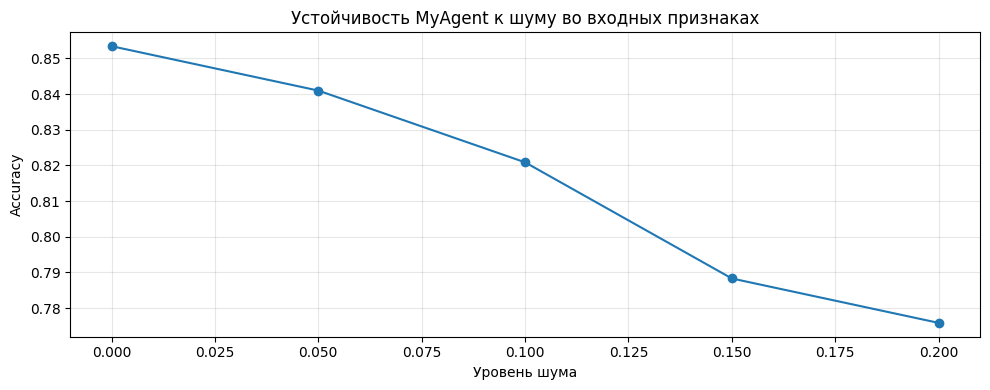

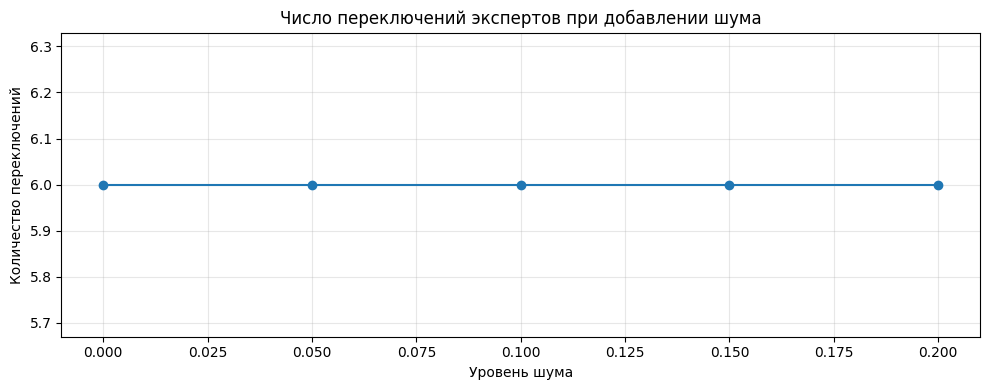

In [89]:
plt.figure(figsize=(10, 4))
plt.plot(
    noise_stability_df["Уровень шума"],
    noise_stability_df["Accuracy MyAgent"],
    marker="o"
)

plt.title("Устойчивость MyAgent к шуму во входных признаках")
plt.xlabel("Уровень шума")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    noise_stability_df["Уровень шума"],
    noise_stability_df["Переключений экспертов"],
    marker="o"
)

plt.title("Число переключений экспертов при добавлении шума")
plt.xlabel("Уровень шума")
plt.ylabel("Количество переключений")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

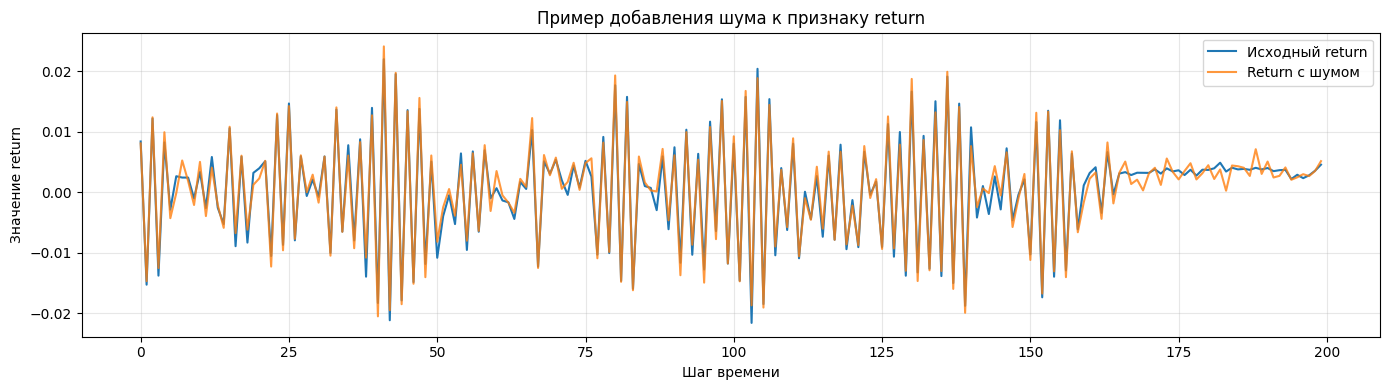

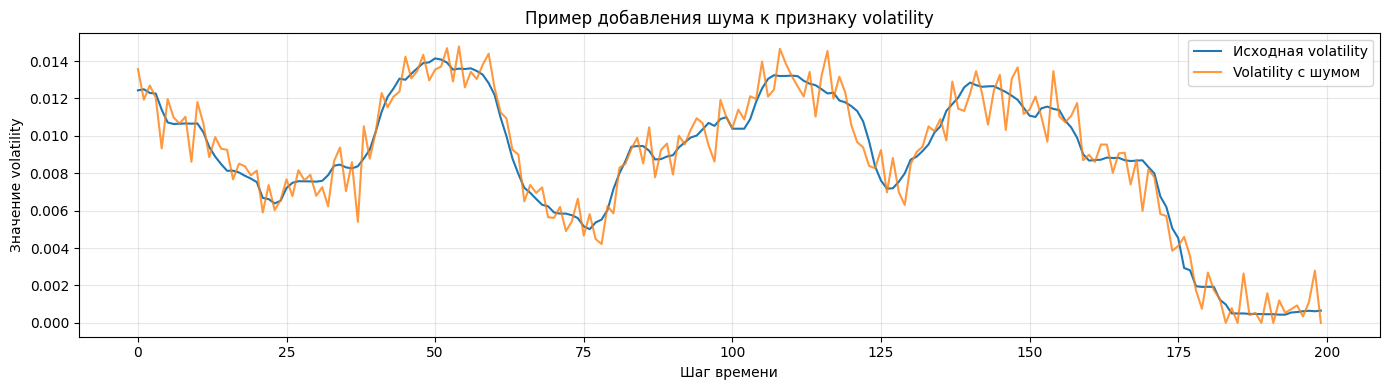

In [90]:
noise_level_for_plot = 0.20

X_test_noisy_for_plot = add_feature_noise(
    X_regime_test,
    noise_level=noise_level_for_plot,
    seed=2028
)

plot_limit = 200
time_index_noise = np.arange(plot_limit)

plt.figure(figsize=(14, 4))
plt.plot(
    time_index_noise,
    X_regime_test[:plot_limit, 0],
    label="Исходный return"
)
plt.plot(
    time_index_noise,
    X_test_noisy_for_plot[:plot_limit, 0],
    label="Return с шумом",
    alpha=0.8
)

plt.title("Пример добавления шума к признаку return")
plt.xlabel("Шаг времени")
plt.ylabel("Значение return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 4))
plt.plot(
    time_index_noise,
    X_regime_test[:plot_limit, 1],
    label="Исходная volatility"
)
plt.plot(
    time_index_noise,
    X_test_noisy_for_plot[:plot_limit, 1],
    label="Volatility с шумом",
    alpha=0.8
)

plt.title("Пример добавления шума к признаку volatility")
plt.xlabel("Шаг времени")
plt.ylabel("Значение volatility")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
noise_effect_df = pd.DataFrame({
    "Признак": ["return", "volatility", "rsi", "ma20_diff", "ma50_diff"],
    "Среднее абсолютное изменение": np.mean(
        np.abs(X_test_noisy_for_plot - X_regime_test),
        axis=0
    ),
    "Максимальное абсолютное изменение": np.max(
        np.abs(X_test_noisy_for_plot - X_regime_test),
        axis=0
    )
})

display(noise_effect_df)

,Признак,Среднее абсолютное изменение,Максимальное абсолютное изменение
0,return,0.001092,0.004076
1,volatility,0.000688,0.003204
2,rsi,0.040392,0.197286
3,ma20_diff,0.003410,0.014303
4,ma50_diff,0.008270,0.037285


### Аналитическая записка

В работе реализован адаптивный агент на базе комитета из пяти предобученных MLP-экспертов. Эксперты были выбраны так, чтобы покрывать основные режимы динамической среды: бычий тренд, медвежий тренд, боковик/флет, высокую волатильность и возврат к среднему. Такой набор позволяет агенту не использовать одну универсальную модель для всех ситуаций, а переключать стратегию в зависимости от текущего состояния временного ряда.

Expert 1: Bull trend MLP обучался для режима устойчивого роста цены. Expert 2: Bear trend MLP предназначен для режима устойчивого снижения. Expert 3: Flat MLP отвечает за боковик, где нет ярко выраженного направления движения. Expert 4: High volatility MLP используется при резких колебаниях и повышенной неопределённости. Expert 5: Mean reversion MLP добавлен как дополнительный эксперт для режима флета, так как в боковом движении цена часто отклоняется от среднего уровня и затем возвращается обратно. Поэтому во флете прогноз формируется как взвешенная комбинация Flat MLP и Mean Reversion MLP.

Решающими признаками для дирижёра стали статистики краткосрочного окна: средняя доходность, стандартное отклонение доходности, средняя волатильность, доля положительных изменений и среднее отклонение от MA20. Эти признаки позволяют отличать направленный рост, направленное падение, боковое движение и режим высокой волатильности. Для повышения устойчивости используется механизм подтверждения смены режима: новый режим должен подтвердиться несколько раз подряд, поэтому агент не переключается из-за одиночного шумового выброса.

Итоговая архитектура работает по схеме: входные признаки → окно памяти → расширенные признаки → определение режима → выбор MLP-эксперта или группы экспертов → прогноз направления цены. На тестовом полигоне со сменой режимов адаптивный агент показал качество выше лучшей одиночной MLP-модели, а стресс-тест с добавлением шума показал, что число переключений не растёт хаотично при искажении входных признаков.